# Project 48 — PSG-Derived Feature Evaluation
## Sleep Disorder Detection · Signal-Engineered Features

---
### What this CSV is and why it's different

Unlike the previous 628-column questionnaire/demographic CSV, this dataset (136 columns, 2056 subjects) was computed **directly from raw PSG signals** — EEG spectral power per band per sleep stage, HRV metrics, leg movement indices, REM EMG, bruxism, oxygen desaturation curves, and full sleep architecture statistics.

### Pre-analysis findings (run before this notebook)

| Finding | Decision |
|---|---|
| **Zero missing values** across all 132 features | No imputation or row dropping needed |
| **No constant or near-constant columns** | No variance-based dropping needed |
| **`EEG1_N2_Sigma_mean` == `EEG1_N2_Sigma_Power_mean`** (exact duplicate) | Drop one |
| **HRV columns (SDNN, RMSSD, etc.)** have 544/2056 zeros (26%) — zeros = failed computation, not true zero; values are physiologically impossible at face value (SDNN=435,452) → raw samples, not ms | Replace zeros with NaN → median impute → log1p transform |
| **MeanHR per stage** (N1/N2/N3/R/W) has 91–95% zeros — essentially unusable | Drop all 5 |
| **28 highly correlated pairs** (\|r\|>0.95) — e.g. T90_sec↔T90_pct, R_Duration↔REM_Epochs_N, many EEG band pairs | Correlation pruning at 0.95 |
| **Extreme outliers** in nearly every feature (z>5) | RobustScaler (IQR-based) instead of StandardScaler |
| **EEG power features span 1e-14 to 0.5+** — heavily right-skewed | Log1p transform before scaling |
| **HRV_LF_ms2 max = 5.45e12** — astronomically skewed | Log1p transform |
| **No stability selection needed** — only 132 features, clean, no noise columns from questionnaire | Use correlation pruning + mutual information filter instead (faster, more appropriate) |

### Target class rates
| Target | Positive rate |
|---|---|
| Insomnia | 6.3% (130/2056) |
| RLS | 4.5% (92/2056) |
| Apnea | 7.6% (156/2056) |

## 1. Install & Import

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import (
    StratifiedKFold, cross_val_predict,
    train_test_split, learning_curve
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    f1_score, roc_auc_score
)

import xgboost as xgb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

print(f'PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using: {DEVICE}')

PyTorch 2.9.0+cu126 | CUDA: True
Using: cuda


## 2. Configuration

In [2]:
CSV_PATH       = '/kaggle/input/datasets/girishgiriirig/mesa-clinical-features/output.csv'  # update path
TARGET_COLUMNS = ['Insomnia', 'RLS', 'apnea']
TARGET_LABELS  = {'Insomnia': 'Insomnia', 'RLS': 'RLS', 'apnea': 'Apnea'}
ID_COL         = 'nsrrid'

# ── Columns to drop (analysis-justified) ────────────────────────────────────
# Exact duplicate
DUPLICATE_COLS  = ['EEG1_N2_Sigma_mean']
# 91-95% zeros = effectively missing per sleep stage
SPARSE_HR_COLS  = ['MeanHR_W_bpm','MeanHR_N1_bpm','MeanHR_N2_bpm',
                   'MeanHR_N3_bpm','MeanHR_R_bpm']

# ── HRV columns needing zero→NaN + log1p treatment ──────────────────────────
HRV_RAW_COLS    = ['HRV_SDNN_ms','HRV_RMSSD_ms','HRV_MeanRR_ms',
                   'HRV_MeanHR_bpm','HRV_LF_ms2','HRV_HF_ms2','HRV_LF_HF']

# ── EEG power columns to log1p (heavily right-skewed, tiny values) ───────────
# All columns starting with EEG1_ and containing Power or Intrusion or Hyperarousal
# — detected from scale analysis (range 1e-14 to 0.66)
EEG_LOG_KEYWORDS = ['_Power_', 'Intrusion', 'Hyperarousal', 'SWA_ratio',
                    'Desaturation_AUC', 'Segment_Duration_Variance']

# ── Feature selection ────────────────────────────────────────────────────────
CORR_THRESHOLD = 0.95    # drop one of each highly correlated pair
MI_PERCENTILE  = 30      # keep features above 30th percentile of MI score
                          # (adaptive: keeps different counts per target)

# ── Model / CV ───────────────────────────────────────────────────────────────
CV_FOLDS     = 3
TEST_SIZE    = 0.2
RANDOM_STATE = 42

DL_EPOCHS     = 60
DL_BATCH_SIZE = 64
DL_LR         = 1e-3

# ── Plot style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#2e3250',   'axes.labelcolor': '#c9cde0',
    'xtick.color': '#8b90a8',      'ytick.color': '#8b90a8',
    'text.color': '#c9cde0',       'grid.color': '#2e3250',
    'grid.linestyle': '--',        'grid.alpha': 0.5,
    'font.family': 'monospace',
})
MODEL_COLORS = {
    'LogisticReg' : '#4fc3f7',
    'RandomForest': '#81c784',
    'XGBoost'     : '#ffb74d',
    'LinearSVM'   : '#ce93d8',
    'MLP_sklearn' : '#f48fb1',
    'MLP_PyTorch' : '#ff6e6e',
}

print('✅ Config loaded')

✅ Config loaded


## 3. Preprocessing Pipeline

Every decision here is backed by the pre-analysis:
- No imputation needed (zero missing)
- Drop duplicate + sparse columns
- Fix HRV zeros → log1p
- Log1p skewed EEG power features
- RobustScaler (IQR-based) for outlier resistance

In [3]:
def preprocess(df, target):
    """
    Full preprocessing for PSG-derived CSV.
    Returns X_scaled (np.ndarray), y (pd.Series), feature_names (list)
    """
    drop_cols = [ID_COL] + TARGET_COLUMNS + DUPLICATE_COLS + SPARSE_HR_COLS
    X = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()
    y = df[target].copy()

    # ── Fix HRV: zeros = failed computation → treat as missing → median ──
    for col in HRV_RAW_COLS:
        if col in X.columns:
            X[col] = X[col].replace(0, np.nan)
            X[col] = X[col].fillna(X[col].median())

    # ── Log1p transform: HRV (astronomical scale) + EEG power (tiny+skewed) ─
    for col in X.columns:
        should_log = (
            col in HRV_RAW_COLS or
            any(kw in col for kw in EEG_LOG_KEYWORDS)
        )
        if should_log:
            X[col] = np.log1p(X[col].clip(lower=0))

    # ── RobustScaler (handles outlier-heavy distributions) ────────────────
    feature_names = X.columns.tolist()
    X_scaled = RobustScaler().fit_transform(X)

    print(f'  Features after preprocessing: {len(feature_names)}')
    return X_scaled, y, feature_names


def correlation_pruning(X, feature_names, threshold=CORR_THRESHOLD):
    """
    Drop one column from each pair with |r| > threshold.
    Keeps the first encountered in each correlated group.
    """
    df_tmp = pd.DataFrame(X, columns=feature_names)
    corr   = df_tmp.corr().abs()
    upper  = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    keep    = [f for f in feature_names if f not in to_drop]
    idx     = [feature_names.index(f) for f in keep]
    print(f'  Correlation pruning: {len(feature_names)} → {len(keep)} features '
          f'(dropped {len(to_drop)})')
    return X[:, idx], keep


def mi_filter(X, y, feature_names, percentile=MI_PERCENTILE):
    """
    Keep features above the given MI percentile.
    Appropriate here because dataset is clean — no noise columns to fight.
    """
    mi     = mutual_info_classif(X, y, random_state=RANDOM_STATE)
    cutoff = np.percentile(mi, percentile)
    mask   = mi >= cutoff
    keep   = [f for f, m in zip(feature_names, mask) if m]
    mi_df  = pd.Series(mi, index=feature_names).sort_values(ascending=False)
    print(f'  MI filter (>{percentile}th pct, cutoff={cutoff:.5f}): '
          f'{len(feature_names)} → {len(keep)} features')
    print(f'  Top 10 by MI:')
    print(mi_df.head(10).to_string())
    return X[:, mask], keep, mi_df


print('✅ Preprocessing functions ready')

✅ Preprocessing functions ready


## 4. Model Zoo

In [4]:
def get_models(pos_weight=1.0):
    return {
        'LogisticReg': LogisticRegression(
            penalty='elasticnet', solver='saga',
            l1_ratio=0.5, C=0.1,
            class_weight='balanced',
            max_iter=3000, n_jobs=-1, random_state=RANDOM_STATE
        ),
        'RandomForest': RandomForestClassifier(
            n_estimators=300, max_depth=8,
            class_weight='balanced',
            n_jobs=-1, random_state=RANDOM_STATE
        ),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=300, learning_rate=0.05,
            max_depth=4, subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=pos_weight,
            eval_metric='logloss', verbosity=0,
            n_jobs=-1, random_state=RANDOM_STATE
        ),
        'LinearSVM': CalibratedClassifierCV(
            LinearSVC(C=0.1, class_weight='balanced',
                      max_iter=3000, random_state=RANDOM_STATE),
            cv=3
        ),
        'MLP_sklearn': MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation='relu', max_iter=300,
            early_stopping=True, validation_fraction=0.15,
            random_state=RANDOM_STATE
        ),
    }

print('✅ Model zoo ready')

✅ Model zoo ready


## 5. PyTorch Deep MLP

In [5]:
class DeepMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),        nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)


def train_deep_mlp(X_tr, y_tr, X_val, y_val):
    X_t = torch.tensor(X_tr, dtype=torch.float32).to(DEVICE)
    y_t = torch.tensor(y_tr.values, dtype=torch.float32).to(DEVICE)
    X_v = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
    y_v = torch.tensor(y_val.values, dtype=torch.float32).to(DEVICE)

    loader    = DataLoader(TensorDataset(X_t, y_t), batch_size=DL_BATCH_SIZE, shuffle=True)
    neg, pos  = (y_tr==0).sum(), (y_tr==1).sum()
    pos_w     = torch.tensor([neg/max(pos,1)], dtype=torch.float32).to(DEVICE)
    model     = DeepMLP(X_tr.shape[1]).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    optimizer = optim.AdamW(model.parameters(), lr=DL_LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=DL_EPOCHS)

    tr_losses, vl_losses, tr_accs, vl_accs = [], [], [], []

    for epoch in range(DL_EPOCHS):
        model.train()
        ep_loss = ep_correct = ep_total = 0
        for Xb, yb in loader:
            optimizer.zero_grad()
            logits = model(Xb)
            loss   = criterion(logits, yb)
            loss.backward(); optimizer.step()
            ep_loss    += loss.item() * len(yb)
            ep_correct += ((torch.sigmoid(logits)>0.5).float()==yb).sum().item()
            ep_total   += len(yb)
        scheduler.step()

        model.eval()
        with torch.no_grad():
            v_logits = model(X_v)
            v_loss   = criterion(v_logits, y_v).item()
            v_acc    = ((torch.sigmoid(v_logits)>0.5).float()==y_v).float().mean().item()

        tr_losses.append(ep_loss/ep_total); vl_losses.append(v_loss)
        tr_accs.append(ep_correct/ep_total); vl_accs.append(v_acc)

        if (epoch+1) % 20 == 0:
            print(f'    Epoch [{epoch+1:>2}/{DL_EPOCHS}]  '
                  f'Train loss={tr_losses[-1]:.4f} acc={tr_accs[-1]:.4f}  '
                  f'Val loss={vl_losses[-1]:.4f} acc={vl_accs[-1]:.4f}')

    return model, tr_losses, vl_losses, tr_accs, vl_accs


def dl_proba(model, X):
    model.eval()
    with torch.no_grad():
        return torch.sigmoid(
            model(torch.tensor(X, dtype=torch.float32).to(DEVICE))
        ).cpu().numpy()

print('✅ PyTorch DeepMLP ready')

✅ PyTorch DeepMLP ready


## 6. Plotting Utilities

In [6]:
def tune_threshold(y_true, probs):
    prec, rec, thr = precision_recall_curve(y_true, probs)
    f1 = 2*prec*rec/(prec+rec+1e-9)
    return thr[np.argmax(f1)]


def plot_confusion_matrices(y_true, y_pred, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    fig.patch.set_facecolor('#0f1117')
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    for ax, data, fmt, t in zip(
        axes, [cm, cm_pct], ['d', '.1f'],
        [f'{title} — Count', f'{title} — Row-Normalised (%)']):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                    linewidths=0.5, linecolor='#2e3250',
                    annot_kws={'size':13,'weight':'bold'})
        ax.set_title(t, pad=12, color='#c9cde0')
        ax.set_xlabel('Predicted', color='#8b90a8')
        ax.set_ylabel('Actual',    color='#8b90a8')
        ax.set_xticklabels(['Negative','Positive'], rotation=0)
        ax.set_yticklabels(['Negative','Positive'], rotation=0)
    plt.tight_layout(); plt.show()


def plot_roc(results, title):
    fig, ax = plt.subplots(figsize=(7,6))
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='Random')
    for name, res in results.items():
        fpr, tpr, _ = roc_curve(res['y_true'], res['probs'])
        ax.plot(fpr, tpr, lw=2, color=MODEL_COLORS.get(name,'#fff'),
                label=f'{name} (AUC={auc(fpr,tpr):.3f})')
    ax.set_title(f'{title} — ROC', pad=12)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right', fontsize=8, framealpha=0.3)
    ax.grid(True); plt.tight_layout(); plt.show()


def plot_pr(results, title, baseline):
    fig, ax = plt.subplots(figsize=(7,6))
    ax.axhline(y=baseline, color='#555', lw=1, ls='--',
               label=f'No-skill ({baseline:.3f})')
    for name, res in results.items():
        prec, rec, _ = precision_recall_curve(res['y_true'], res['probs'])
        ap = average_precision_score(res['y_true'], res['probs'])
        ax.step(rec, prec, where='post', lw=2,
                color=MODEL_COLORS.get(name,'#fff'),
                label=f'{name} (AP={ap:.3f})')
    ax.set_title(f'{title} — PR Curve', pad=12)
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
    ax.legend(loc='upper right', fontsize=8, framealpha=0.3)
    ax.grid(True); plt.tight_layout(); plt.show()


def _diagnose(ax, gap):
    if gap > 0.15:
        txt, col = f'⚠ Overfitting  (gap={gap:.2f})', '#ff6e6e'
    elif gap < -0.05:
        txt, col = f'⚠ Underfitting (val > train)', '#ffb74d'
    else:
        txt, col = f'✓ Good fit     (gap={gap:.2f})', '#81c784'
    ax.text(0.02, 0.04, txt, transform=ax.transAxes,
            color=col, fontsize=9, fontweight='bold')


def plot_learning_curve(model, X, y, mname, label):
    tr_sz, tr_sc, vl_sc = learning_curve(
        model, X, y,
        cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
        scoring='average_precision',
        train_sizes=np.linspace(0.2, 1.0, 5),
        n_jobs=-1
    )
    tr_m, vl_m = tr_sc.mean(1), vl_sc.mean(1)
    tr_s, vl_s = tr_sc.std(1),  vl_sc.std(1)
    fig, ax = plt.subplots(figsize=(7,5))
    ax.fill_between(tr_sz, tr_m-tr_s, tr_m+tr_s, alpha=0.15, color='#4fc3f7')
    ax.fill_between(tr_sz, vl_m-vl_s, vl_m+vl_s, alpha=0.15, color='#ffb74d')
    ax.plot(tr_sz, tr_m, 'o-', color='#4fc3f7', lw=2, label='Train PR-AUC')
    ax.plot(tr_sz, vl_m, 's-', color='#ffb74d', lw=2, label='CV Val PR-AUC')
    ax.set_title(f'{label} · {mname} — Learning Curve', pad=12)
    ax.set_xlabel('Training samples'); ax.set_ylabel('PR-AUC')
    ax.legend(fontsize=9, framealpha=0.3); ax.grid(True)
    _diagnose(ax, float(tr_m[-1]-vl_m[-1]))
    plt.tight_layout(); plt.show()


def plot_dl_curves(tr_l, vl_l, tr_a, vl_a, label):
    epochs = range(1, len(tr_l)+1)
    fig, axes = plt.subplots(1, 2, figsize=(13,5))
    fig.patch.set_facecolor('#0f1117')
    fig.suptitle(f'{label} · MLP_PyTorch — Training Diagnostics',
                 color='#c9cde0', fontsize=12)
    for ax, tr, vl, ylabel, metric in zip(
        axes, [tr_l, tr_a], [vl_l, vl_a],
        ['BCE Loss','Accuracy'], ['Loss','Acc']):
        ax.plot(epochs, tr, color='#4fc3f7', lw=2, label=f'Train {metric}')
        ax.plot(epochs, vl, color='#ff6e6e', lw=2, label=f'Val {metric}')
        ax.set_title(f'{ylabel} per Epoch')
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.legend(fontsize=9, framealpha=0.3); ax.grid(True)
        gap = (vl[-1]-tr[-1]) if metric=='Loss' else (tr[-1]-vl[-1])
        _diagnose(ax, gap)
    plt.tight_layout(); plt.show()


def plot_mi_bar(mi_series, label, n=20):
    """Bar chart of top MI features."""
    top = mi_series.head(n)
    fig, ax = plt.subplots(figsize=(9, n*0.35 + 1))
    ax.barh(top.index[::-1], top.values[::-1], color='#4fc3f7', alpha=0.85)
    ax.set_title(f'{label} — Top {n} Features by Mutual Information', pad=12)
    ax.set_xlabel('MI Score')
    ax.grid(True, axis='x')
    plt.tight_layout(); plt.show()


print('✅ Plotting utilities ready')

✅ Plotting utilities ready


## 7. Load Data

In [7]:
df = pd.read_csv(CSV_PATH)
print(f'Loaded: {df.shape[0]} rows × {df.shape[1]} cols')
print(f'Missing values: {df.drop(columns=[ID_COL]).isna().sum().sum()} (total across all cells)')
print()
for t in TARGET_COLUMNS:
    vc  = df[t].value_counts(dropna=False)
    pos = vc.get(1, 0)
    print(f'  {TARGET_LABELS[t]:10s}: {dict(vc)}  pos_rate={pos/len(df)*100:.1f}%')

Loaded: 2056 rows × 136 cols
Missing values: 0 (total across all cells)

  Insomnia  : {0: np.int64(1926), 1: np.int64(130)}  pos_rate=6.3%
  RLS       : {0: np.int64(1964), 1: np.int64(92)}  pos_rate=4.5%
  Apnea     : {0: np.int64(1900), 1: np.int64(156)}  pos_rate=7.6%


## 8. Full Pipeline — Per Target


▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  🎯  INSOMNIA (Insomnia)
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

[1/6] Preprocessing...
  Features after preprocessing: 126
  Samples: 2056  |  Pos: 130  (6.3%)

[2/6] Correlation pruning...
  Correlation pruning: 126 → 106 features (dropped 20)

[3/6] Mutual information filter...
  MI filter (>30th pct, cutoff=0.00000): 106 → 106 features
  Top 10 by MI:
Leg_Burst_N                   0.012089
EEG1_N3_Sigma_Power_std       0.008915
Wake_Interruptions_per_hr     0.008703
Apnea_N_Total                 0.008010
TST_sec                       0.007987
REM_AHI                       0.007982
EEG1_N3_Theta_Power_mean      0.007952
REM_Phasic_EMG_Rate_per_hr    0.007915
EEG1_R_Alpha_Power_mean       0.007890
Apnea_Duration_Mean_sec       0.007251
  Final feature count: 106


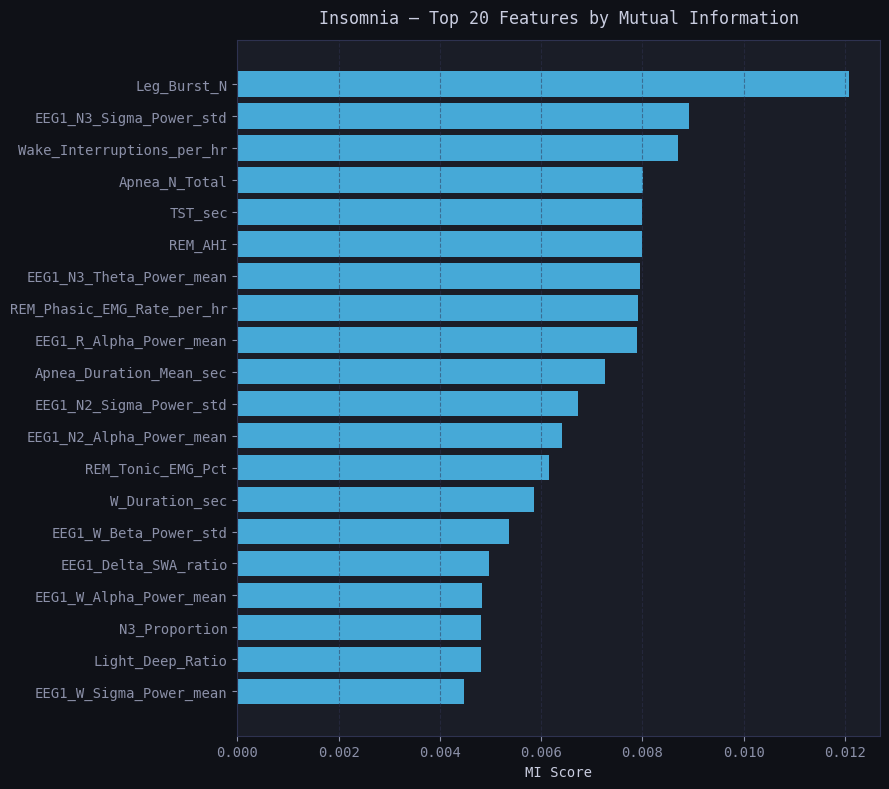


  Train=1644  Test=412  pos_rate=0.063  pos_weight=14.8

[4/6] Training sklearn models...
  ► LogisticReg... 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


F1=0.119  AUROC=0.534  AP=0.070  (22s)
  ► RandomForest... F1=0.120  AUROC=0.496  AP=0.064  (5s)
  ► XGBoost... F1=0.127  AUROC=0.550  AP=0.083  (4s)
  ► LinearSVM... 

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

F1=0.126  AUROC=0.565  AP=0.116  (22s)
  ► MLP_sklearn... F1=0.125  AUROC=0.525  AP=0.079  (1s)

  ► MLP_PyTorch (60 epochs)...
    Epoch [20/60]  Train loss=1.2615 acc=0.4373  Val loss=1.2932 acc=0.1189
    Epoch [40/60]  Train loss=1.2411 acc=0.3631  Val loss=1.2966 acc=0.0947
    Epoch [60/60]  Train loss=1.2472 acc=0.3759  Val loss=1.2892 acc=0.1650
  F1=0.130  AUROC=0.494  AP=0.076  (8s)

[5/6] Classification Reports — Insomnia

  ▸ LogisticReg
              precision    recall  f1-score   support

    Negative     0.9406    0.2461    0.3901       386
    Positive     0.0643    0.7692    0.1187        26

    accuracy                         0.2791       412
   macro avg     0.5025    0.5077    0.2544       412
weighted avg     0.8853    0.2791    0.3730       412


  ▸ RandomForest
              precision    recall  f1-score   support

    Negative     0.9524    0.0518    0.0983       386
    Positive     0.0639    0.9615    0.1199        26

    accuracy                         

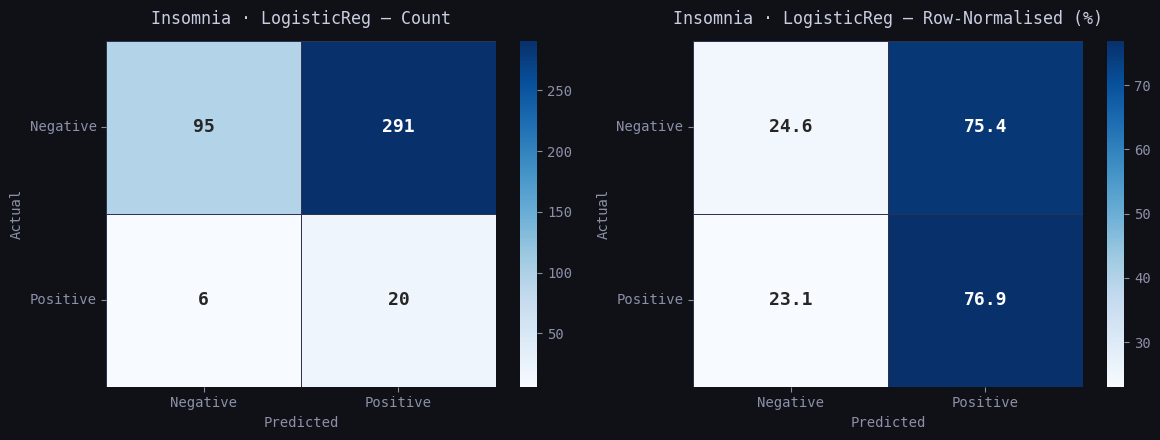

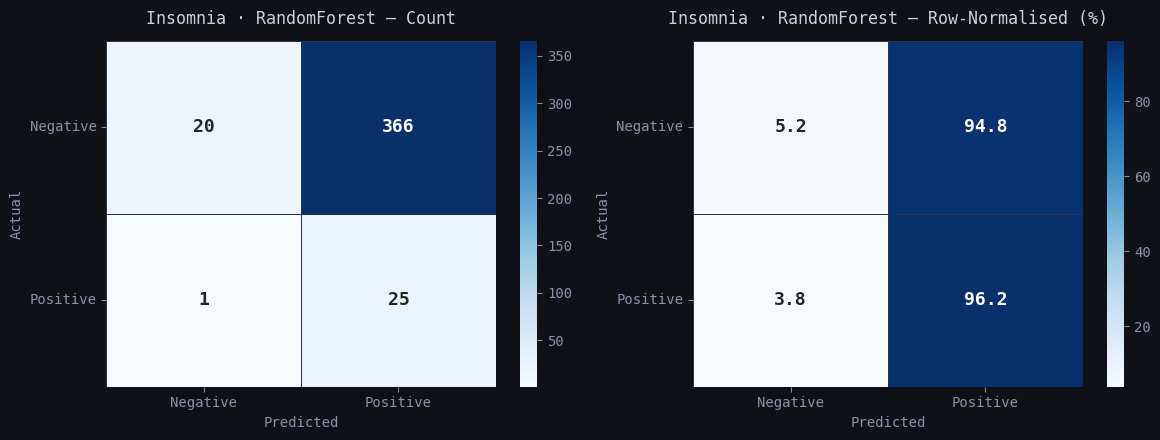

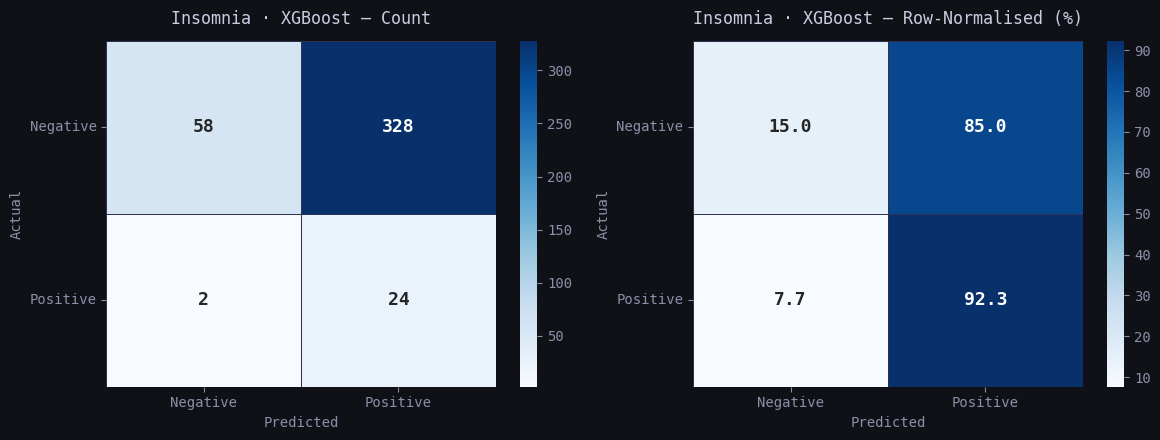

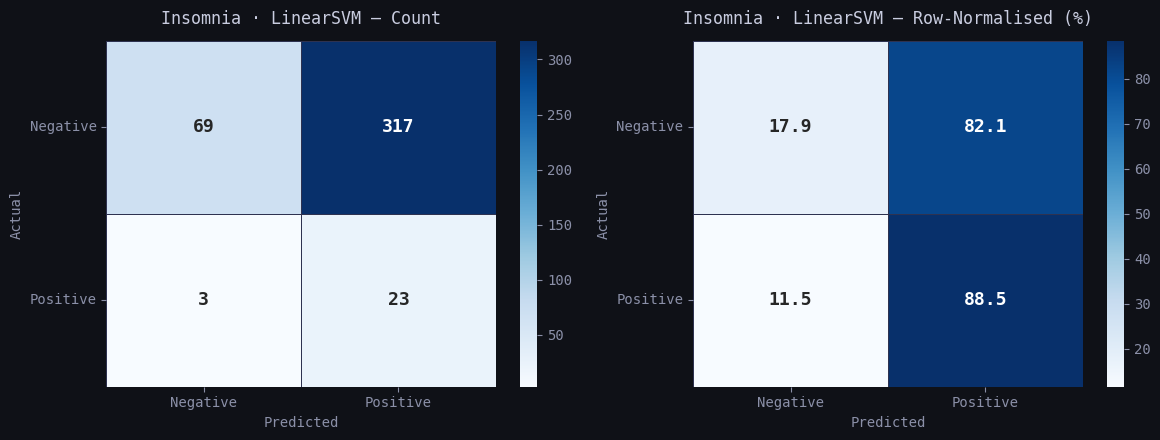

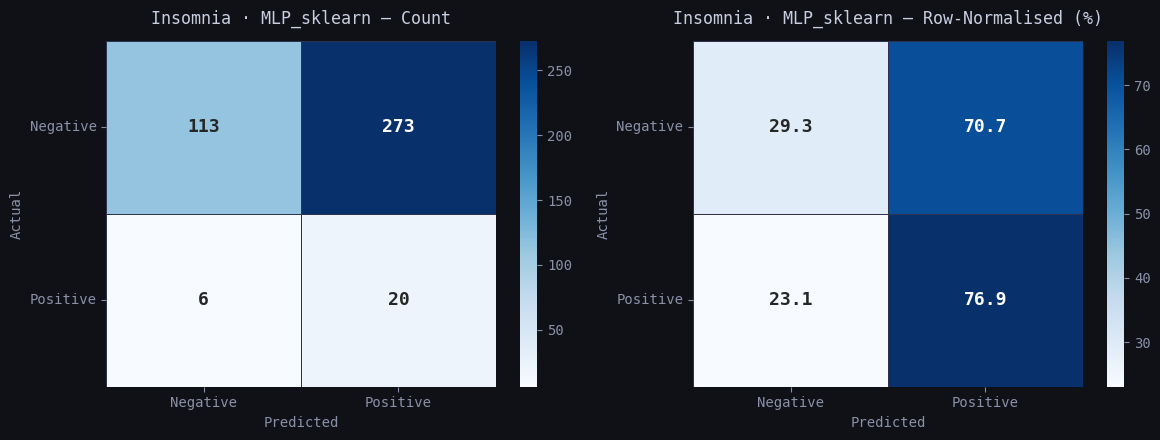

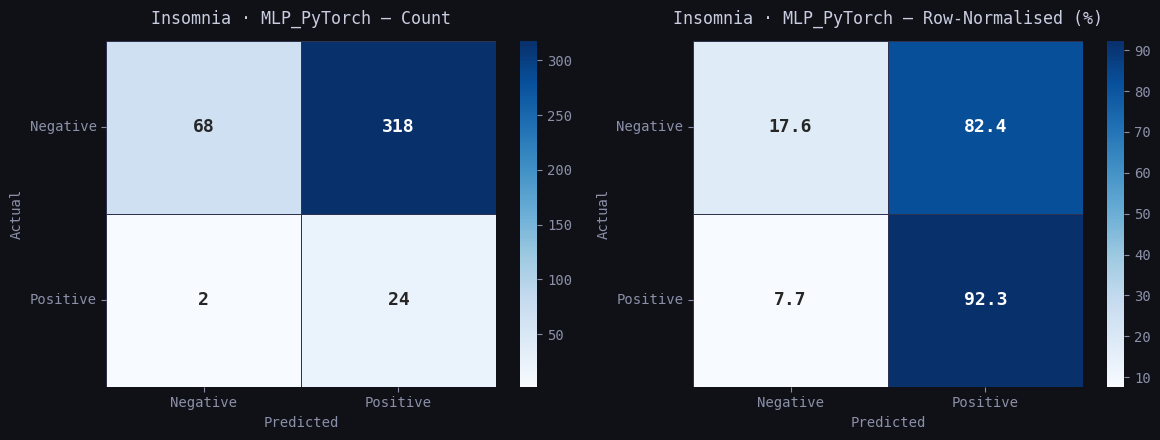

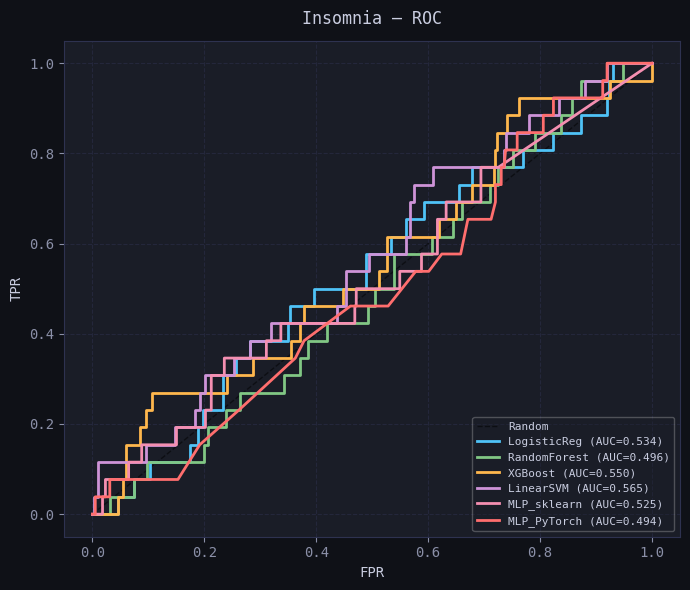

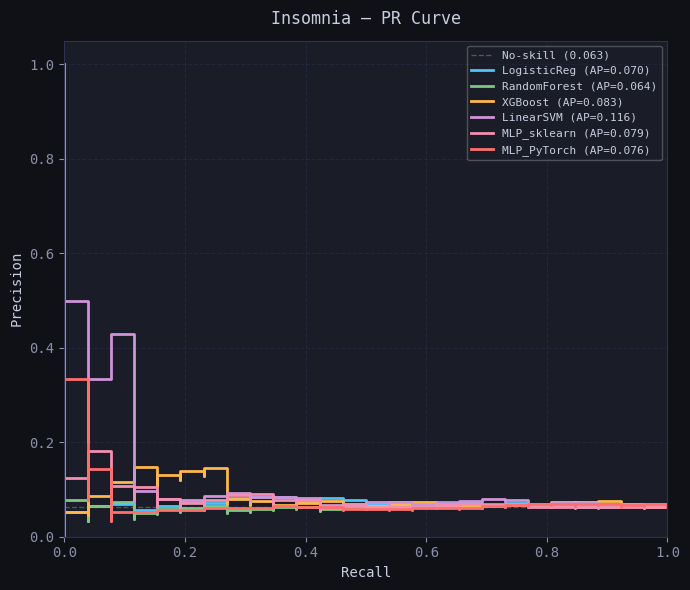


[+] Learning Curves — Insomnia


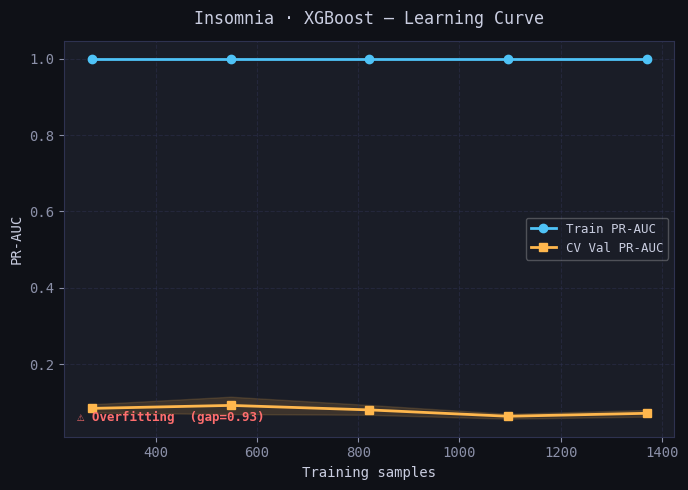

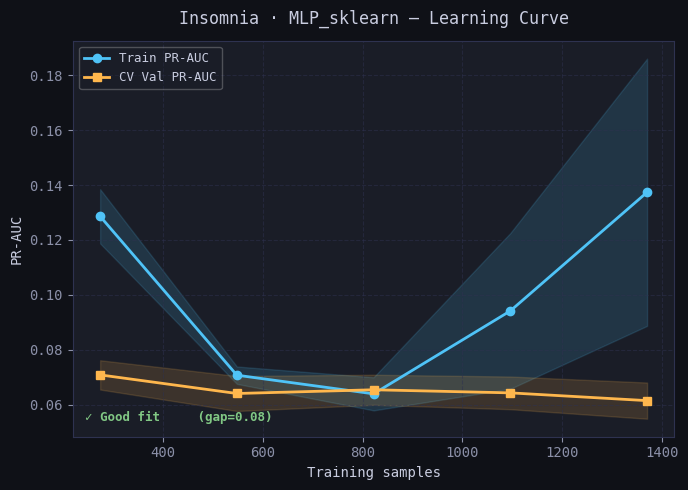


[+] PyTorch Training Curves — Insomnia


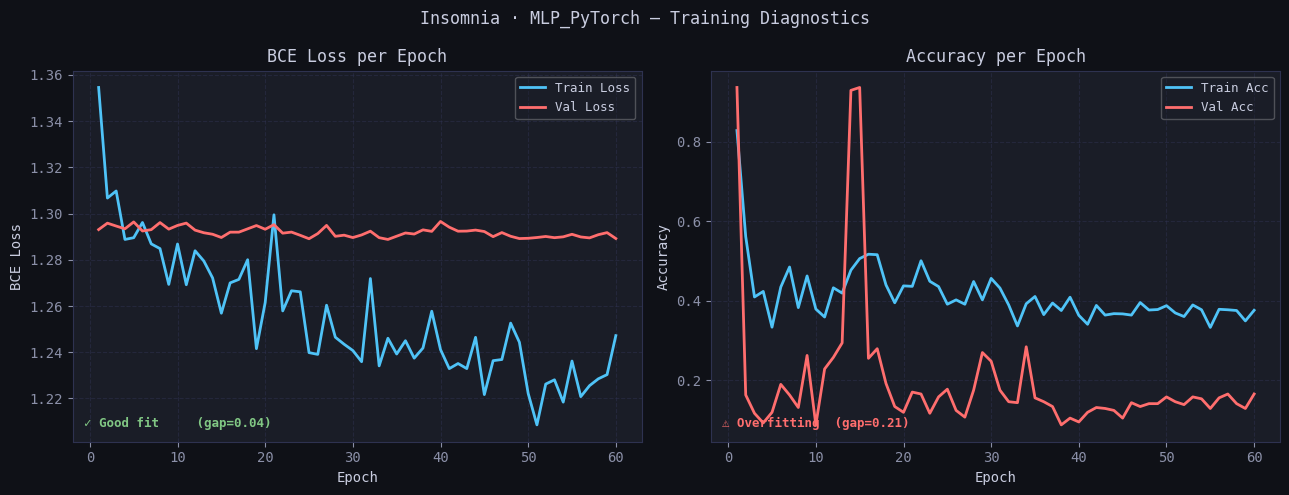


  ⏱ Insomnia total: 1.3 min

▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  🎯  RLS (RLS)
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

[1/6] Preprocessing...
  Features after preprocessing: 126
  Samples: 2056  |  Pos: 92  (4.5%)

[2/6] Correlation pruning...
  Correlation pruning: 126 → 106 features (dropped 20)

[3/6] Mutual information filter...
  MI filter (>30th pct, cutoff=0.00000): 106 → 106 features
  Top 10 by MI:
TIB_sec                       0.009051
AI                            0.008379
REM_Periods                   0.005868
W_Duration_sec                0.005792
REM_Phasic_EMG_Rate_per_hr    0.005478
EEG1_W_Delta_Power_mean       0.005065
REM_Tonic_EMG_Pct             0.004959
R_Proportion                  0.004807
N1_Duration_sec               0.004692
N2_Duration_sec               0.004646
  Final feature count: 106


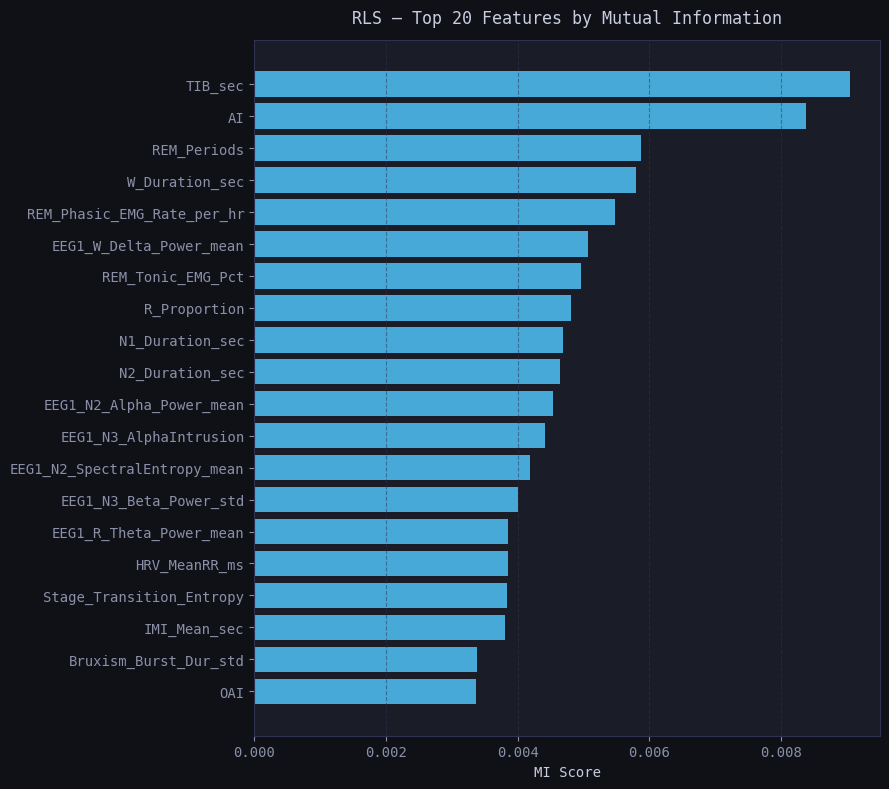


  Train=1644  Test=412  pos_rate=0.045  pos_weight=21.2

[4/6] Training sklearn models...
  ► LogisticReg... 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


F1=0.095  AUROC=0.508  AP=0.055  (21s)
  ► RandomForest... F1=0.105  AUROC=0.651  AP=0.072  (4s)
  ► XGBoost... F1=0.182  AUROC=0.659  AP=0.097  (3s)
  ► LinearSVM... 

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

F1=0.000  AUROC=0.527  AP=0.048  (19s)
  ► MLP_sklearn... F1=0.077  AUROC=0.516  AP=0.049  (1s)

  ► MLP_PyTorch (60 epochs)...
    Epoch [20/60]  Train loss=1.2701 acc=0.6034  Val loss=1.3201 acc=0.0534
    Epoch [40/60]  Train loss=1.2353 acc=0.6849  Val loss=1.3188 acc=0.0583
    Epoch [60/60]  Train loss=1.2766 acc=0.7074  Val loss=1.3162 acc=0.0583
  F1=0.115  AUROC=0.524  AP=0.054  (4s)

[5/6] Classification Reports — RLS

  ▸ LogisticReg
              precision    recall  f1-score   support

    Negative     0.9600    0.7919    0.8679       394
    Positive     0.0575    0.2778    0.0952        18

    accuracy                         0.7694       412
   macro avg     0.5087    0.5348    0.4816       412
weighted avg     0.9206    0.7694    0.8341       412


  ▸ RandomForest
              precision    recall  f1-score   support

    Negative     0.9605    0.8629    0.9091       394
    Positive     0.0690    0.2222    0.1053        18

    accuracy                         0.835

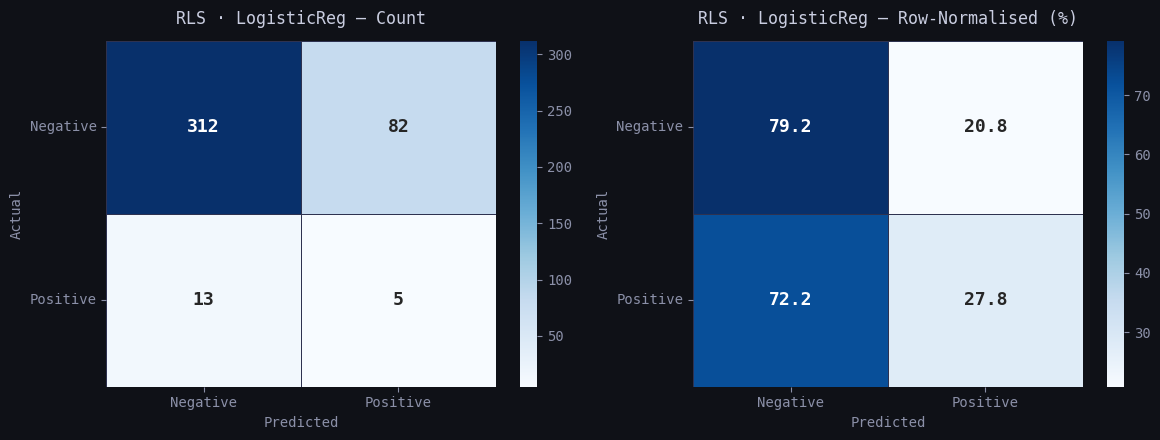

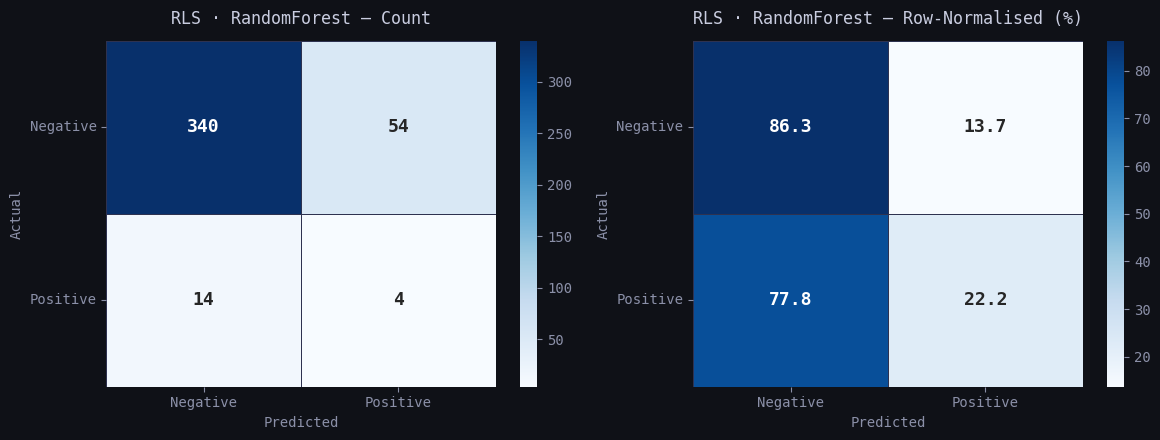

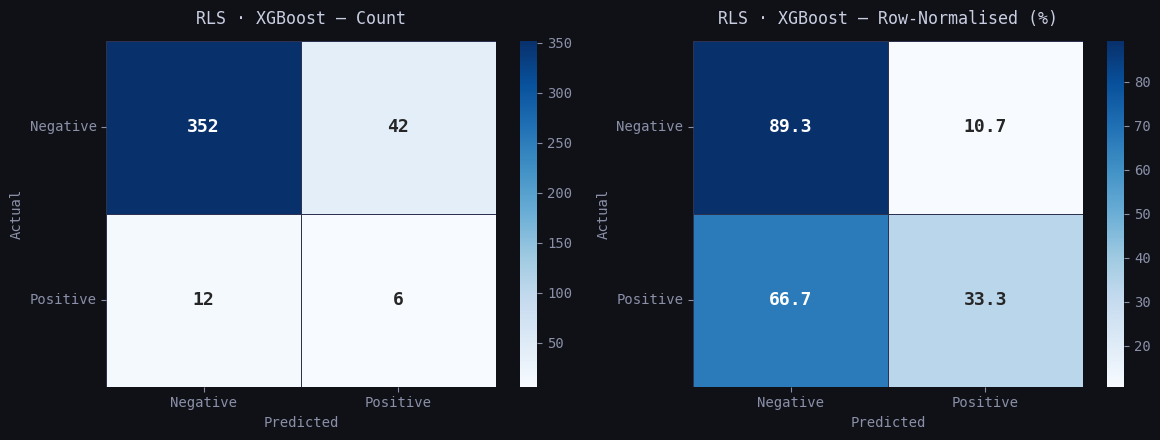

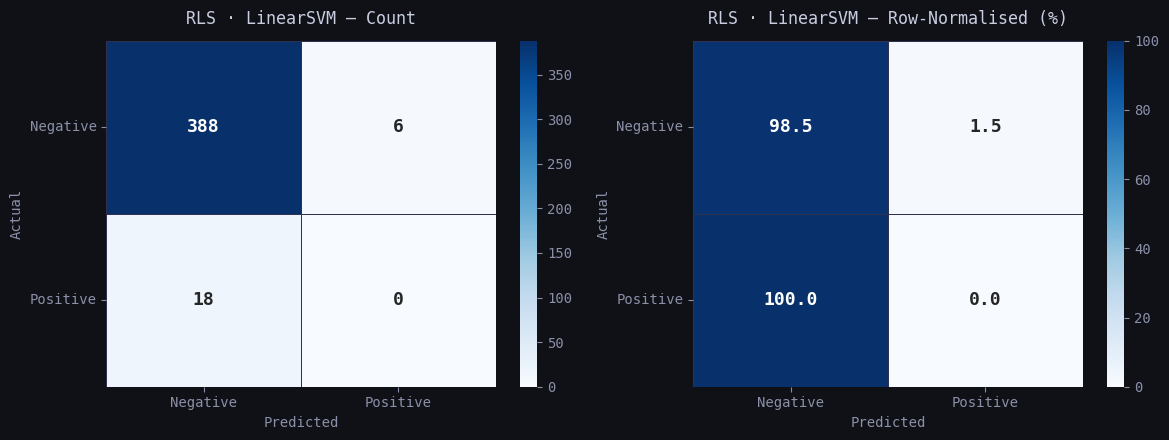

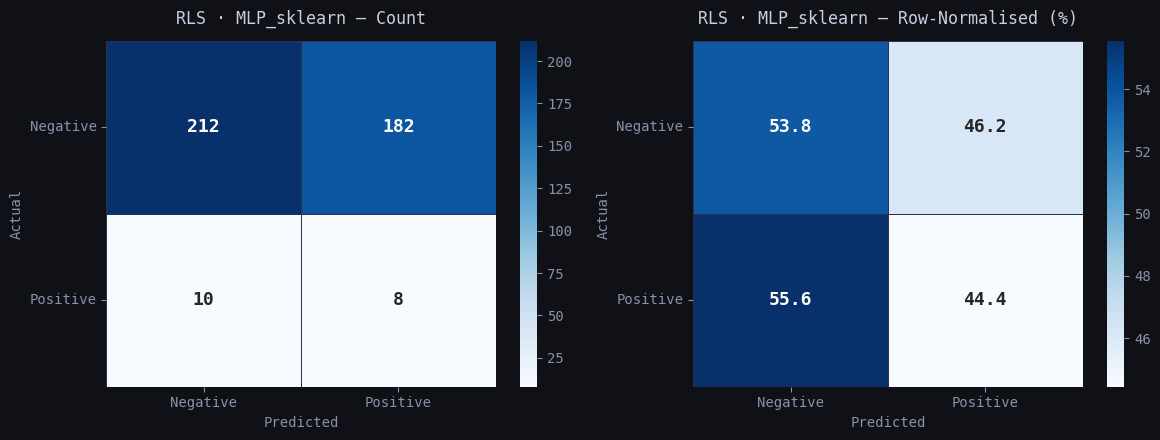

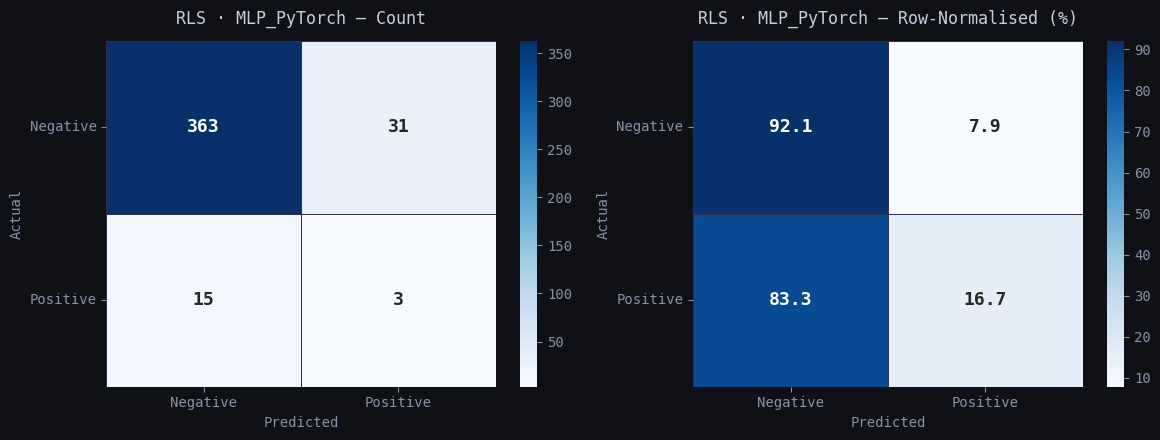

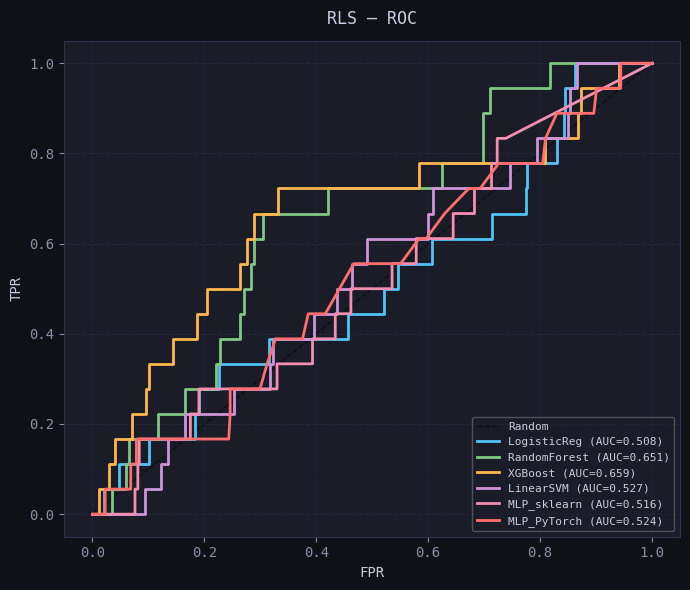

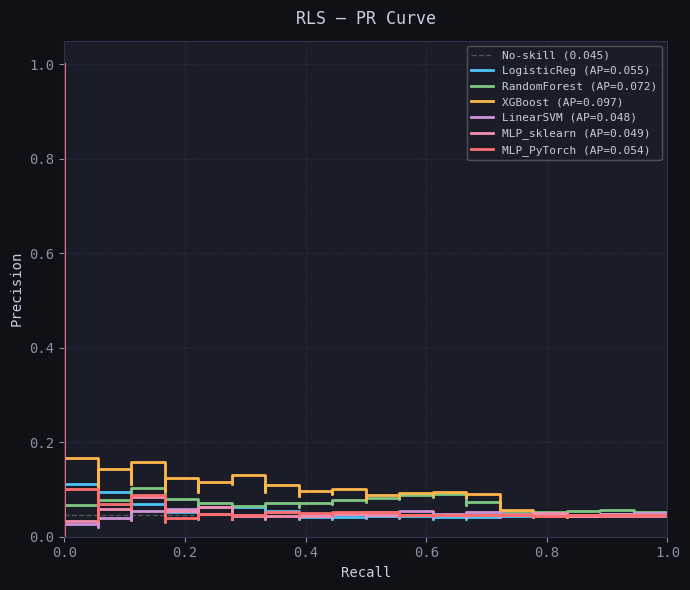


[+] Learning Curves — RLS


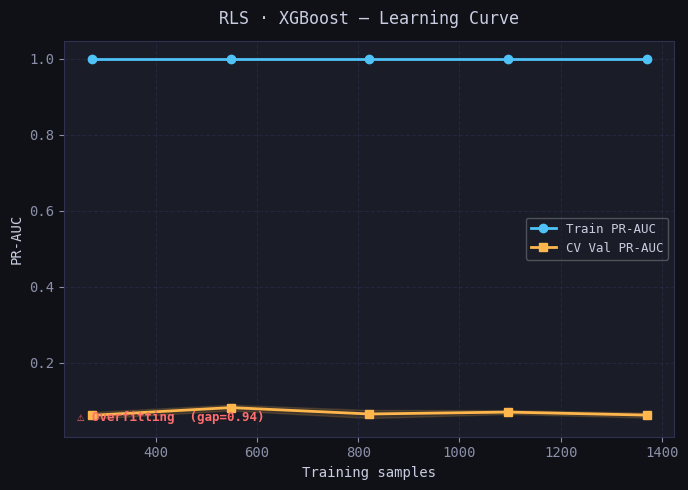

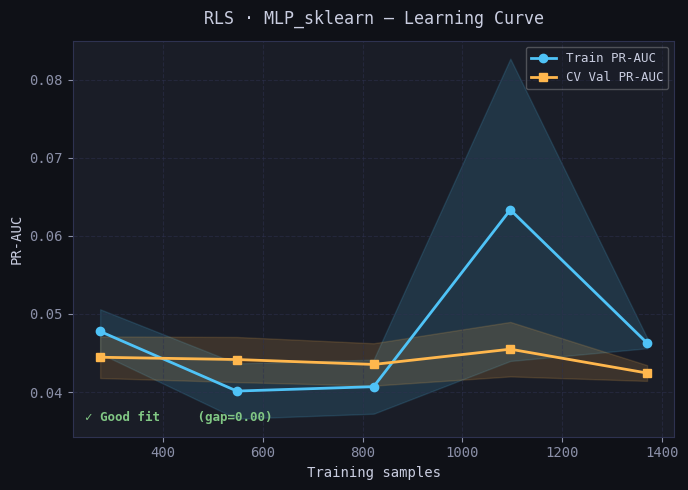


[+] PyTorch Training Curves — RLS


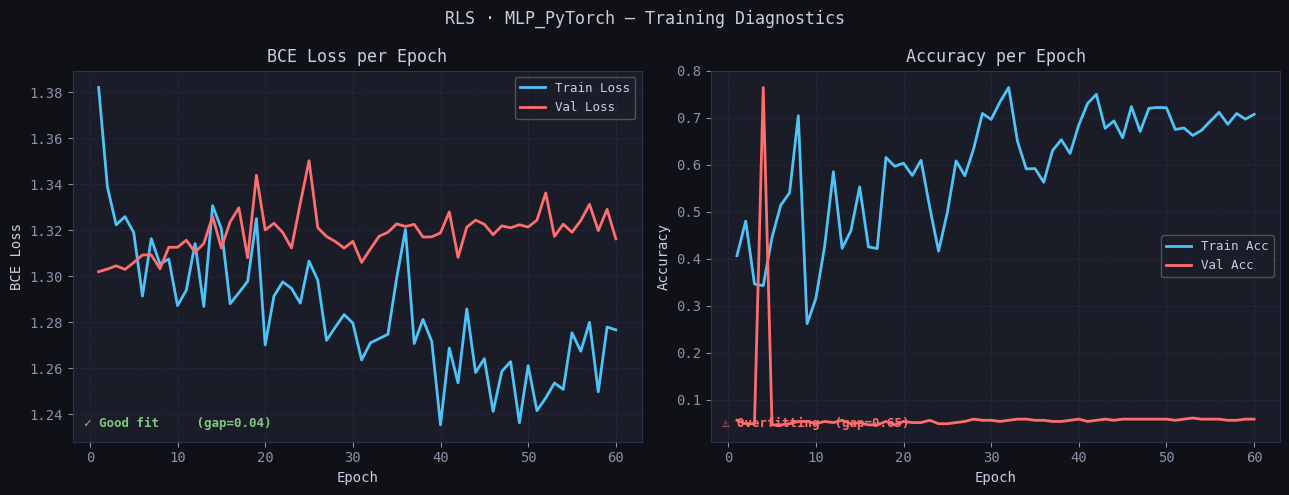


  ⏱ RLS total: 1.1 min

▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  🎯  APNEA (apnea)
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

[1/6] Preprocessing...
  Features after preprocessing: 126
  Samples: 2056  |  Pos: 156  (7.6%)

[2/6] Correlation pruning...
  Correlation pruning: 126 → 106 features (dropped 20)

[3/6] Mutual information filter...
  MI filter (>30th pct, cutoff=0.00000): 106 → 106 features
  Top 10 by MI:
IMI_Std_sec                 0.013486
T90_sec                     0.012864
EEG1_N3_Theta_Power_std     0.012197
Apnea_N_Total               0.011141
W_Duration_sec              0.010648
EEG1_N3_Alpha_Power_std     0.009688
W_Proportion                0.008769
EEG1_W_Beta_Power_std       0.008532
WASO_sec                    0.008396
EEG1_N1_Delta_Power_mean    0.008232
  Final feature count: 106


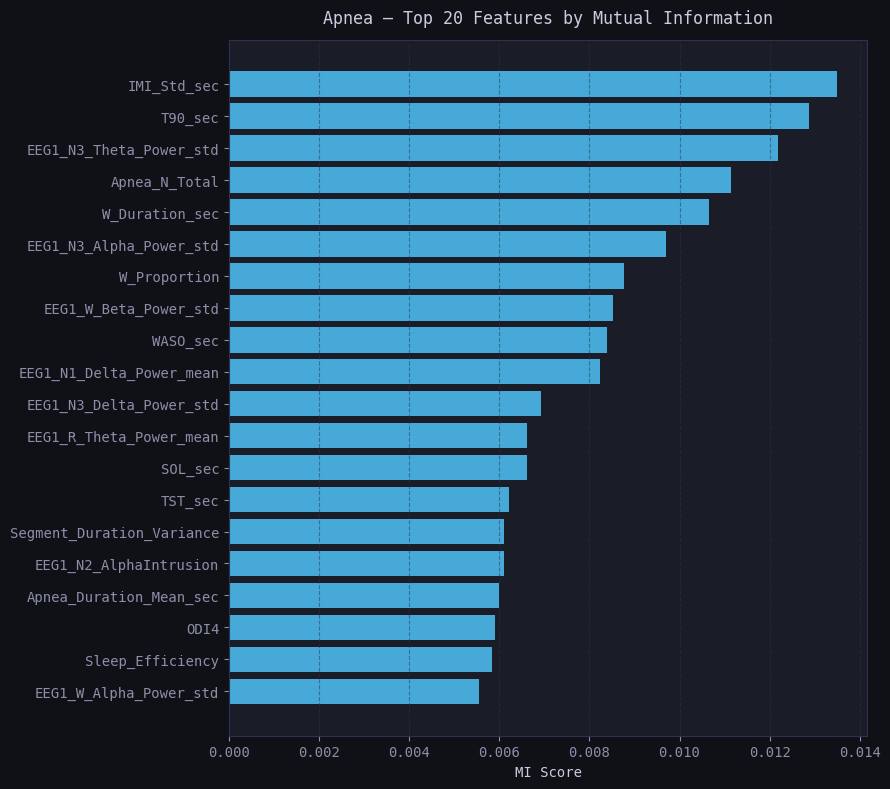


  Train=1644  Test=412  pos_rate=0.076  pos_weight=12.2

[4/6] Training sklearn models...
  ► LogisticReg... 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


F1=0.146  AUROC=0.509  AP=0.076  (21s)
  ► RandomForest... F1=0.183  AUROC=0.623  AP=0.103  (4s)
  ► XGBoost... F1=0.161  AUROC=0.625  AP=0.126  (4s)
  ► LinearSVM... 

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

F1=0.143  AUROC=0.450  AP=0.071  (19s)
  ► MLP_sklearn... F1=0.140  AUROC=0.522  AP=0.079  (1s)

  ► MLP_PyTorch (60 epochs)...
    Epoch [20/60]  Train loss=1.2626 acc=0.5560  Val loss=1.2765 acc=0.0947
    Epoch [40/60]  Train loss=1.2378 acc=0.5170  Val loss=1.2766 acc=0.0898
    Epoch [60/60]  Train loss=1.2787 acc=0.4909  Val loss=1.2828 acc=0.0874
  F1=0.154  AUROC=0.505  AP=0.080  (4s)

[5/6] Classification Reports — Apnea

  ▸ LogisticReg
              precision    recall  f1-score   support

    Negative     0.9370    0.3123    0.4685       381
    Positive     0.0807    0.7419    0.1456        31

    accuracy                         0.3447       412
   macro avg     0.5089    0.5271    0.3070       412
weighted avg     0.8726    0.3447    0.4442       412


  ▸ RandomForest
              precision    recall  f1-score   support

    Negative     0.9611    0.4541    0.6168       381
    Positive     0.1034    0.7742    0.1825        31

    accuracy                         0.4

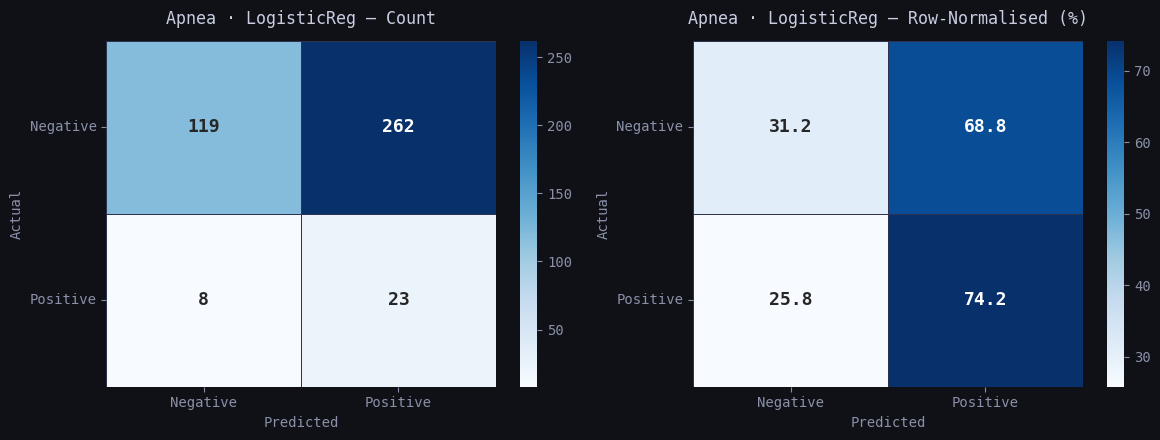

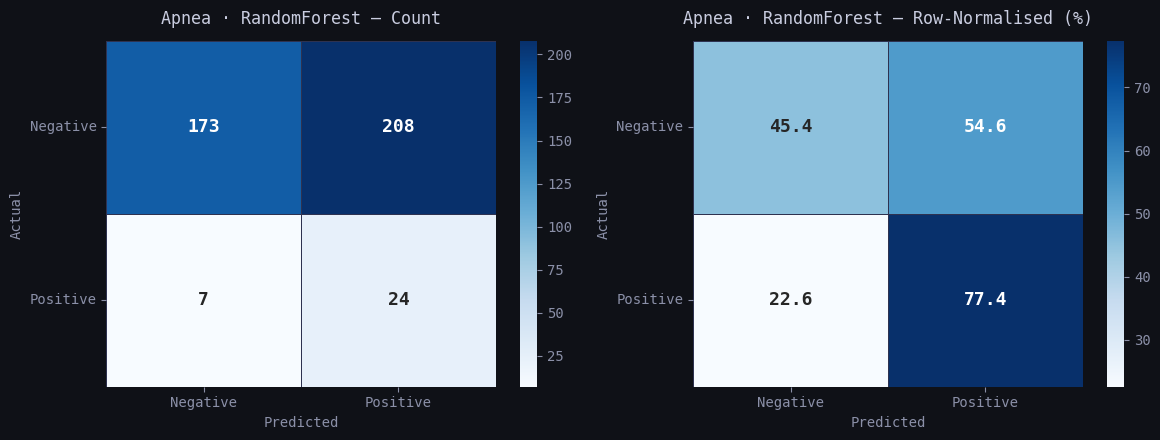

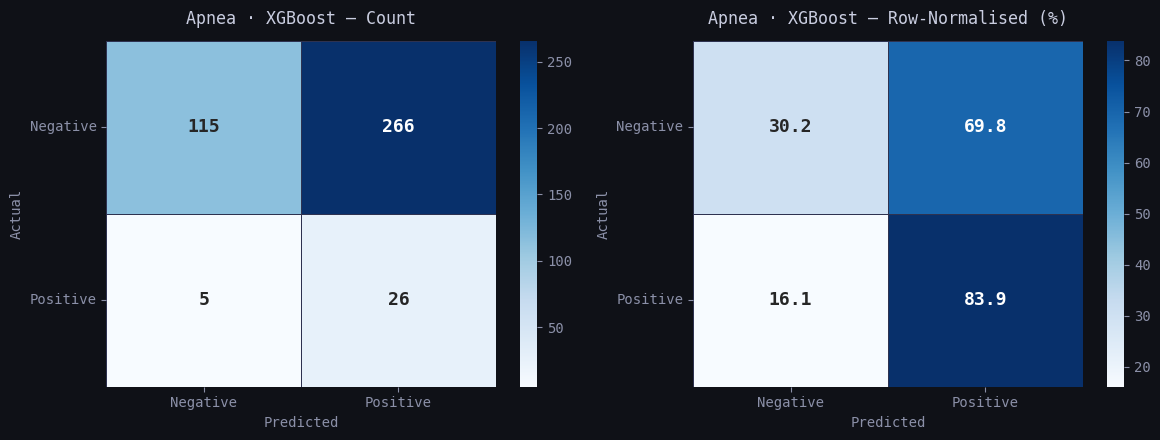

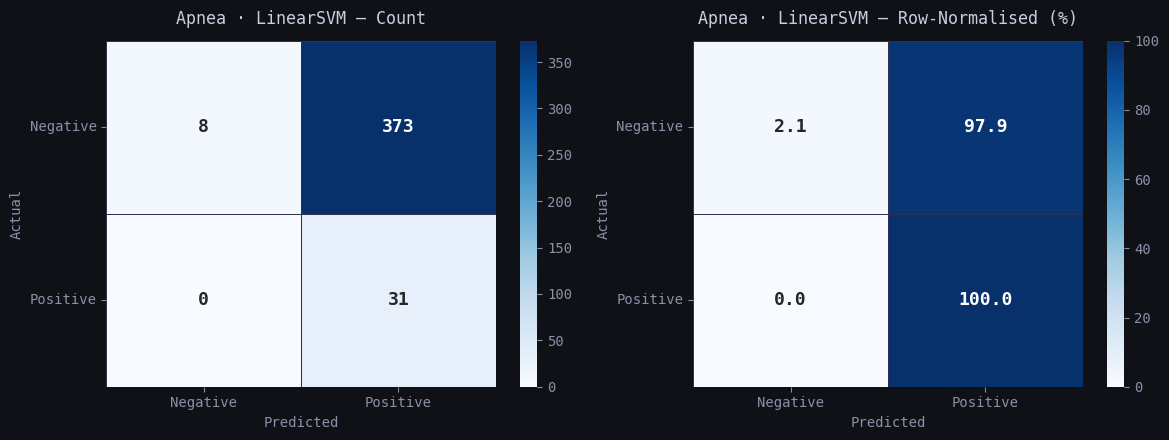

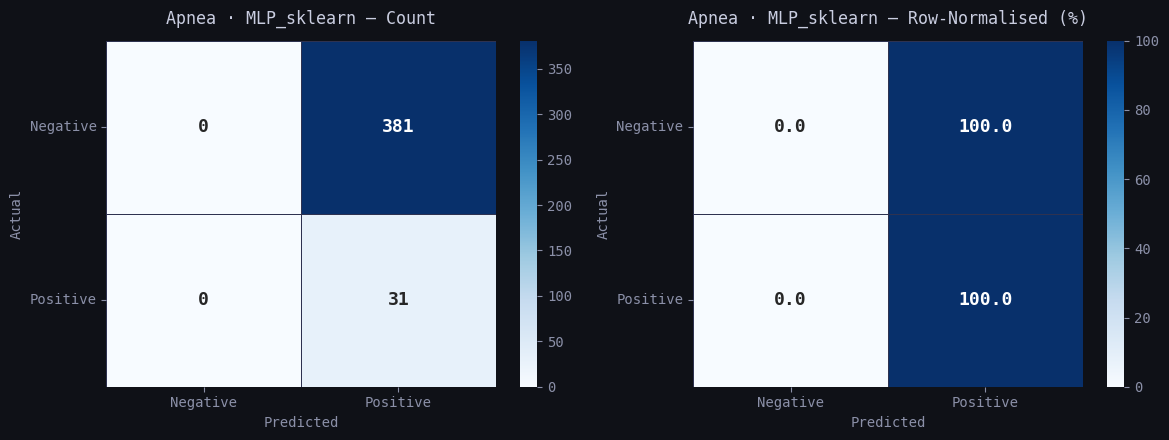

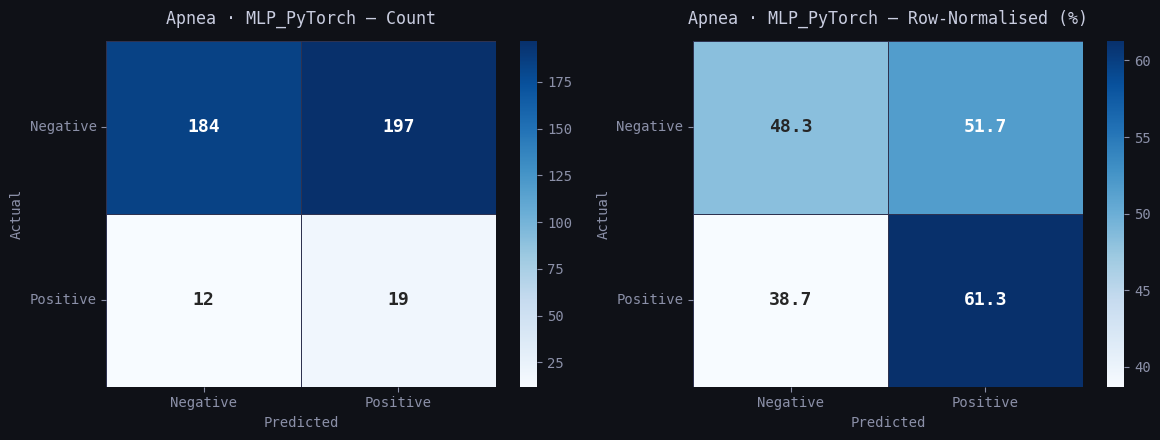

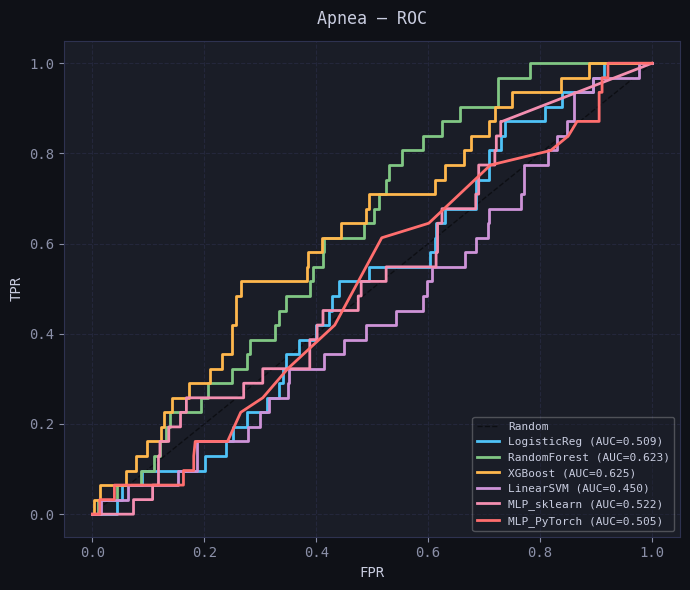

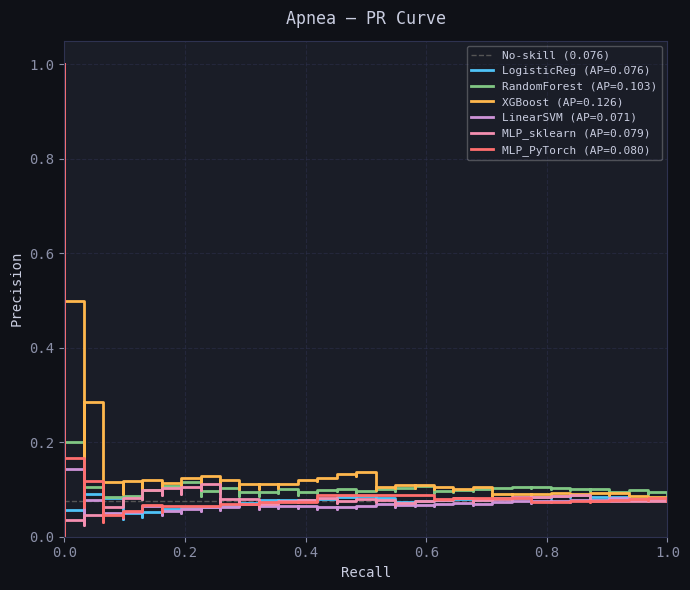


[+] Learning Curves — Apnea


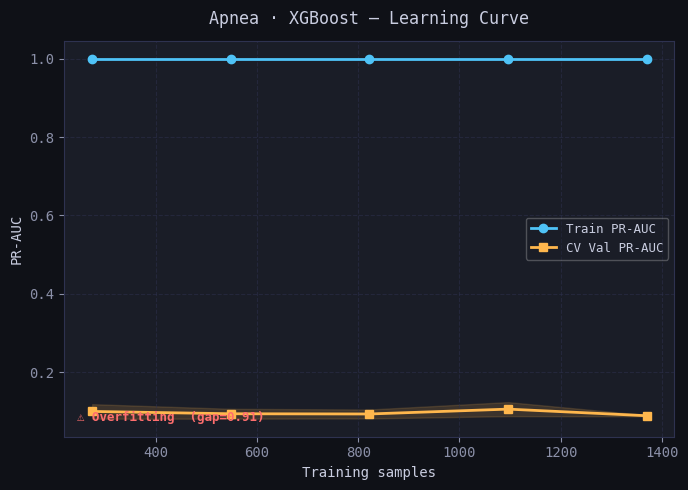

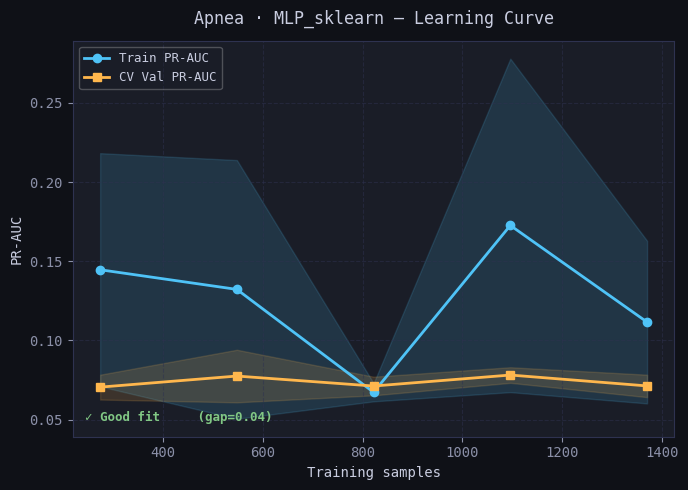


[+] PyTorch Training Curves — Apnea


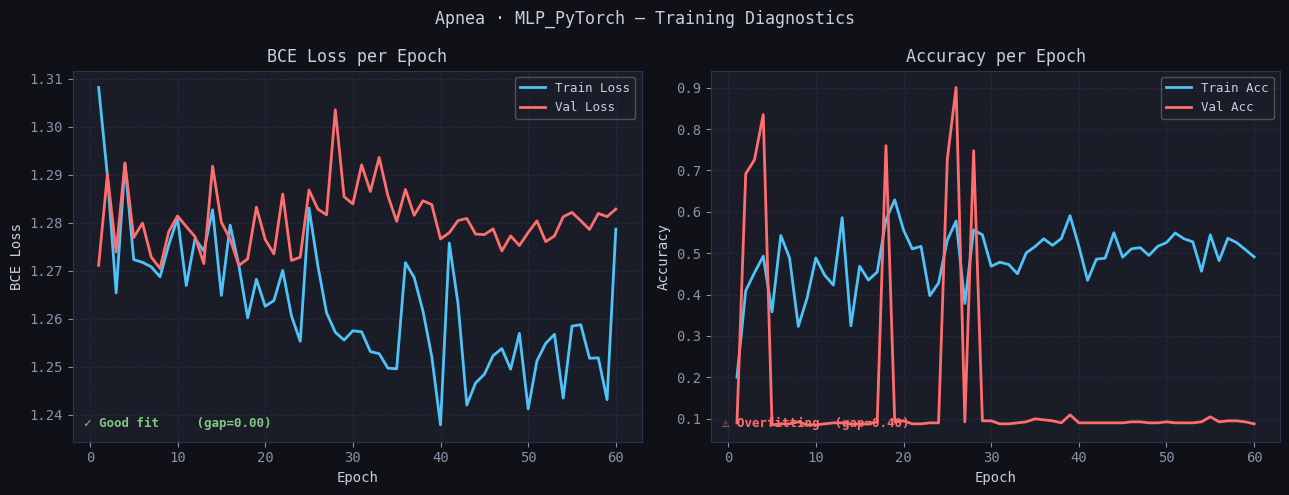


  ⏱ Apnea total: 1.1 min


  🏁 ALL DONE in 3.5 min


In [8]:
all_results = {}
overall_t0  = time.time()

for target in TARGET_COLUMNS:
    label   = TARGET_LABELS[target]
    t_start = time.time()

    print()
    print('▓' * 65)
    print(f'  🎯  {label.upper()} ({target})')
    print('▓' * 65)

    # ── 8.1  Preprocessing ───────────────────────────────────────────────
    print('\n[1/6] Preprocessing...')
    X_pre, y, feat_names = preprocess(df, target)
    print(f'  Samples: {len(y)}  |  Pos: {y.sum()}  ({y.mean()*100:.1f}%)')

    # ── 8.2  Correlation Pruning ─────────────────────────────────────────
    print('\n[2/6] Correlation pruning...')
    X_pruned, feat_pruned = correlation_pruning(X_pre, feat_names)

    # ── 8.3  Mutual Information Filter ───────────────────────────────────
    print('\n[3/6] Mutual information filter...')
    X_final, feat_final, mi_series = mi_filter(X_pruned, y, feat_pruned)
    print(f'  Final feature count: {X_final.shape[1]}')

    # Save MI bar chart
    plot_mi_bar(mi_series, label)

    # Save feature list
    pd.Series(feat_final).to_csv(
        f'/kaggle/working/{target}_psg_features.csv', index=False)

    # ── 8.4  Train / Test Split ──────────────────────────────────────────
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_final, y, test_size=TEST_SIZE,
        stratify=y, random_state=RANDOM_STATE
    )
    baseline_rate = float(y_tr.mean())
    pos_weight    = (y_tr==0).sum() / max((y_tr==1).sum(), 1)
    print(f'\n  Train={len(y_tr)}  Test={len(y_te)}  '
          f'pos_rate={baseline_rate:.3f}  pos_weight={pos_weight:.1f}')

    # ── 8.5  sklearn Models ──────────────────────────────────────────────
    print('\n[4/6] Training sklearn models...')
    target_results = {}
    cv = StratifiedKFold(CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    for mname, model in get_models(pos_weight).items():
        t0 = time.time()
        print(f'  ► {mname}...', end=' ', flush=True)
        oof  = cross_val_predict(model, X_tr, y_tr, cv=cv,
                                 method='predict_proba', n_jobs=-1)[:, 1]
        model.fit(X_tr, y_tr)
        tpr  = model.predict_proba(X_te)[:, 1]
        thr  = tune_threshold(y_tr, oof)
        pred = (tpr >= thr).astype(int)

        f1    = f1_score(y_te, pred, zero_division=0)
        auroc = roc_auc_score(y_te, tpr)
        ap    = average_precision_score(y_te, tpr)
        print(f'F1={f1:.3f}  AUROC={auroc:.3f}  AP={ap:.3f}  ({time.time()-t0:.0f}s)')

        target_results[mname] = {
            'y_true': y_te, 'probs': tpr, 'preds': pred,
            'model': model, 'oof': oof, 'y_tr': y_tr
        }

    # ── 8.6  PyTorch DeepMLP ─────────────────────────────────────────────
    print(f'\n  ► MLP_PyTorch ({DL_EPOCHS} epochs)...')
    t0 = time.time()
    dl_m, tr_l, vl_l, tr_a, vl_a = train_deep_mlp(X_tr, y_tr, X_te, y_te)
    dl_pr   = dl_proba(dl_m, X_te)
    dl_thr  = tune_threshold(y_te, dl_pr)
    dl_pred = (dl_pr >= dl_thr).astype(int)
    dl_f1   = f1_score(y_te, dl_pred, zero_division=0)
    dl_auc  = roc_auc_score(y_te, dl_pr)
    dl_ap   = average_precision_score(y_te, dl_pr)
    print(f'  F1={dl_f1:.3f}  AUROC={dl_auc:.3f}  AP={dl_ap:.3f}  ({time.time()-t0:.0f}s)')
    target_results['MLP_PyTorch'] = {
        'y_true': y_te, 'probs': dl_pr, 'preds': dl_pred,
        'train_losses': tr_l, 'val_losses': vl_l,
        'train_accs': tr_a, 'val_accs': vl_a
    }
    all_results[target] = target_results

    # ── 8.7  Classification Reports ──────────────────────────────────────
    print(f'\n[5/6] Classification Reports — {label}')
    for mname, res in target_results.items():
        print(f'\n  ▸ {mname}')
        print(classification_report(
            res['y_true'], res['preds'],
            target_names=['Negative','Positive'],
            digits=4, zero_division=0
        ))

    # ── 8.8  Confusion Matrices ───────────────────────────────────────────
    print(f'\n[6/6] Confusion Matrices — {label}')
    for mname, res in target_results.items():
        plot_confusion_matrices(res['y_true'], res['preds'], f'{label} · {mname}')

    # ── 8.9  ROC + PR ─────────────────────────────────────────────────────
    plot_roc(target_results, label)
    plot_pr(target_results, label, baseline_rate)

    # ── 8.10  Learning Curves ─────────────────────────────────────────────
    print(f'\n[+] Learning Curves — {label}')
    for mname in ['XGBoost', 'MLP_sklearn']:
        plot_learning_curve(target_results[mname]['model'], X_final, y, mname, label)

    # ── 8.11  DL Epoch Curves ─────────────────────────────────────────────
    print(f'\n[+] PyTorch Training Curves — {label}')
    plot_dl_curves(tr_l, vl_l, tr_a, vl_a, label)

    print(f'\n  ⏱ {label} total: {(time.time()-t_start)/60:.1f} min')

print(f'\n\n  🏁 ALL DONE in {(time.time()-overall_t0)/60:.1f} min')

## 9. Global Summary

In [9]:
rows = []
for target, res_dict in all_results.items():
    for mname, res in res_dict.items():
        rows.append({
            'Target' : TARGET_LABELS[target],
            'Model'  : mname,
            'F1'     : round(f1_score(res['y_true'], res['preds'], zero_division=0), 4),
            'AUROC'  : round(roc_auc_score(res['y_true'], res['probs']), 4),
            'PR-AUC' : round(average_precision_score(res['y_true'], res['probs']), 4),
        })

summary = pd.DataFrame(rows).sort_values(['Target','F1'], ascending=[True,False])
print('\n📊  FULL RESULTS — PSG-Derived Features')
display(summary)
summary.to_csv('/kaggle/working/psg_experiment_summary.csv', index=False)

print('\n🏆  BEST MODEL PER TARGET')
best = summary.loc[summary.groupby('Target')['F1'].idxmax()]
display(best)

print('\n  Phase 3 baseline (questionnaire CSV, best per target):')
print('  Apnea   F1=0.7843  AUROC=0.8835  [XGBoost]')
print('  Insomnia F1=0.3881  AUROC=0.7597  [MLP_PyTorch]')
print('  RLS     F1=0.1553  AUROC=0.6308  [MLP_PyTorch]')


📊  FULL RESULTS — PSG-Derived Features


,Target,Model,F1,AUROC,PR-AUC
13,Apnea,RandomForest,0.1825,0.6233,0.1032
14,Apnea,XGBoost,0.1610,0.6249,0.1263
17,Apnea,MLP_PyTorch,0.1538,0.5054,0.0799
12,Apnea,LogisticReg,0.1456,0.5093,0.0759
15,Apnea,LinearSVM,0.1425,0.4501,0.0706
16,Apnea,MLP_sklearn,0.1400,0.5220,0.0790
5,Insomnia,MLP_PyTorch,0.1304,0.4941,0.0756
2,Insomnia,XGBoost,0.1270,0.5504,0.0830
3,Insomnia,LinearSVM,0.1257,0.5652,0.1162
4,Insomnia,MLP_sklearn,0.1254,0.5245,0.0788



🏆  BEST MODEL PER TARGET


,Target,Model,F1,AUROC,PR-AUC
13,Apnea,RandomForest,0.1825,0.6233,0.1032
5,Insomnia,MLP_PyTorch,0.1304,0.4941,0.0756
8,RLS,XGBoost,0.1818,0.6595,0.0973



  Phase 3 baseline (questionnaire CSV, best per target):
  Apnea   F1=0.7843  AUROC=0.8835  [XGBoost]
  Insomnia F1=0.3881  AUROC=0.7597  [MLP_PyTorch]
  RLS     F1=0.1553  AUROC=0.6308  [MLP_PyTorch]
